In [ ]:
import math
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate
from qiskit.visualization import plot_distribution

[Grover's algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers)

In [16]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states
 
    Here we assume all input marked states have the same number of bits
 
    Parameters:
        marked_states (str or list): Marked states of oracle
 
    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])
 
    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bitstring to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bitstring
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]
        # Add a multi-controlled Z-gate with pre- and post-applied X-gates (open-controls)
        # where the target bitstring has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    return qc

[Diffuser](https://www.scibits.blog/posts/grover/#diffuser)

In [17]:
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    # Apply transformation |psi> -> |00...0> (H-gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    # Apply transformation |00...0> -> |11...1> (X-gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    # Do multi-controlled-Z gate
    qc.h(nqubits-1)
    qc.mcx(list(range(nqubits-1)), nqubits-1)  # multi-controlled-toffoli
    qc.h(nqubits-1)
    # Apply transformation |11...1> -> |00...0>
    for qubit in range(nqubits):
        qc.x(qubit)
    # Apply transformation |00...0> -> |psi>
    for qubit in range(nqubits):
        qc.h(qubit)
    # We will return the diffuser as a gate
    D = qc.to_gate()
    D.name = "D"

    return D

In [18]:
def run_grover(oracle):
    n = oracle.num_qubits 
    
    qc = QuantumCircuit(n)
    
    qc.h(range(n)) # Create even superposition of all basis states

    N = 2**n
    A = 1 # We don't know how many marked states there are
    theta = math.asin(math.sqrt(A / N))
    t = math.floor(math.pi / (4 * theta))
    
    for _ in range(t): # Apply Grover iterations the optimal number of times
        qc.append(oracle, range(n))
        qc.append(diffuser(n), range(n))

    print("Bloch Sphere:")
    plot_bloch_multivector(Statevector.from_instruction(qc))

    qc.measure_all()
    
    return qc

Oracle:
Bloch Sphere:
Circuit:


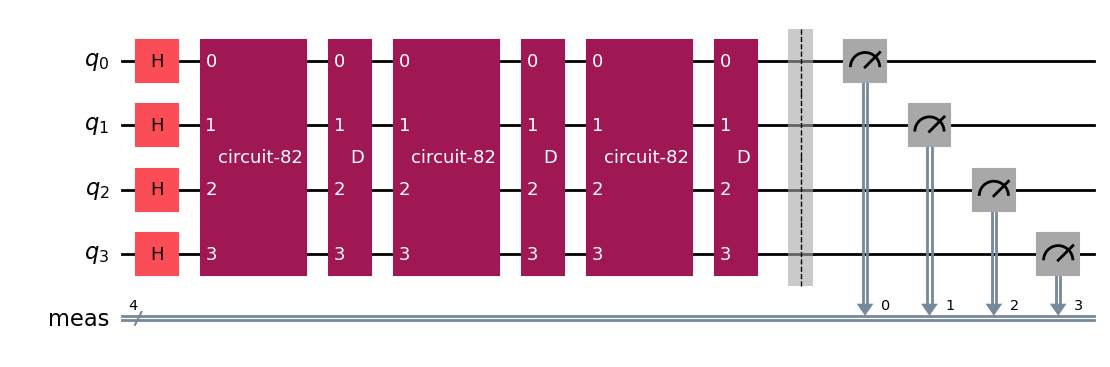

In [19]:
marked_states = ["1110"]
oracle = grover_oracle(marked_states)

print("Oracle:")
oracle.draw(output="mpl", style="iqp")

final_circuit = run_grover(oracle)

print("Circuit:")
final_circuit.draw("mpl")

In [20]:
shots = 500

backend = AerSimulator()
job = backend.run(final_circuit, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {state : count / shots for state, count in counts.items()}
print(f"Probabilities 500 shots:")
plot_histogram(probabilities)

print("The marked states are:")
least_prob = min(probabilities.values())
highest_prob = max(probabilities.values())
threshold = (least_prob + highest_prob) / 2
for state, prob in probabilities.items():
	if prob > threshold or highest_prob - least_prob < 0.05:
		print(f"|{state}>")

AerError: 'unknown instruction: circuit-82'